[INFO] PROJECT_ROOT = C:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis
[INFO] CSV exists: True -> C:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis\ncr_ride_bookings_with_weather_filled_scaled_short.csv
[INFO] Artifacts will be saved under: C:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis\supervised

===== TRAINING SUMMARY =====
Best model        : rf
Validation report : {'model': 'rf', 'accuracy': 0.768270640793916, 'precision': 0.7607839545745947, 'recall': 0.9136101182293098, 'f1': 0.8302226219923543, 'roc_auc': 0.8166301479482068}
Saved model (.pkl): C:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis\supervised\best_cls_rf__target_completed_.pkl
Preds CSV         : C:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis\supervised\cls_best_rf_preds.csv
Split CSV         : C:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis\supervised\split_assignments_classification.csv

===== CLASSIFICATION REPORT (validation) =====
              precision    recall  f1-score   support

           0     

<Figure size 640x480 with 0 Axes>

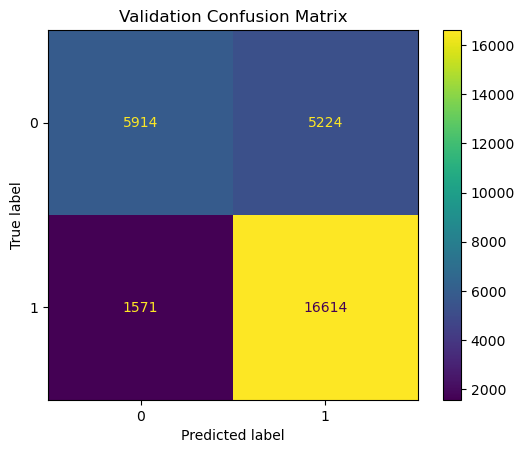


===== PREVIEW: validation predictions =====


,y_true,y_pred,proba
0,1,1,0.640000
1,0,0,0.383333
2,0,0,0.223333
3,0,0,0.490000
4,1,1,0.836667


In [3]:
# === Supervised modeling (save to root-level ./supervised) ===

import os, sys, pathlib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

def add_project_root(marker_folder="project_package", max_up=6):
    cur = pathlib.Path(".").resolve()
    for _ in range(max_up + 1):
        if (cur / marker_folder).is_dir():
            if str(cur) not in sys.path:
                sys.path.insert(0, str(cur))
            return cur
        cur = cur.parent
    raise RuntimeError(f"Could not find '{marker_folder}' up to {max_up} levels above.")

PROJECT_ROOT = add_project_root()
print("[INFO] PROJECT_ROOT =", PROJECT_ROOT)

# locate CSV
CSV_NAME = "ncr_ride_bookings_with_weather_filled_scaled_short.csv"
csv_path = PROJECT_ROOT / CSV_NAME
if not csv_path.exists():
    alt = PROJECT_ROOT / "datasets" / pathlib.Path(CSV_NAME).name
    if alt.exists():
        csv_path = alt
print("[INFO] CSV exists:", csv_path.exists(), "->", csv_path)
if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found at {csv_path}")

from project_package.modeling import train_classification_from_csv

# ✅ Save directly to the root-level `./supervised/` folder (sibling of `Model/`)
ARTIFACTS_DIR = PROJECT_ROOT / "supervised"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
print("[INFO] Artifacts will be saved under:", ARTIFACTS_DIR)

res = train_classification_from_csv(
    csv_path=str(csv_path),
    target_col=None,
    id_cols=["Booking ID", "Customer ID"],
    artifacts_dir=str(ARTIFACTS_DIR),
    valid_ratio=0.20,
    random_state=42,
    tune_row_cap=40000,
)

print("\n===== TRAINING SUMMARY =====")
print("Best model        :", res.best_model_name)
print("Validation report :", res.report)
print("Saved model (.pkl):", res.model_path)
print("Preds CSV         :", res.preds_csv_path)
print("Split CSV         :", res.split_csv_path)

# quick diagnostics
preds = pd.read_csv(res.preds_csv_path)
y_true = preds["y_true"].values
y_pred = preds["y_pred"].values
print("\n===== CLASSIFICATION REPORT (validation) =====")
print(classification_report(y_true, y_pred, digits=4))

if "proba" in preds.columns:
    try:
        print("ROC AUC:", round(roc_auc_score(y_true, preds["proba"].values), 4))
    except Exception as e:
        print("AUC unavailable:", e)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure()
disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()

print("\n===== PREVIEW: validation predictions =====")
display(preds.head())
